In [ ]:
#import shutil
#shutil.rmtree('/content/drive')  # removes the folder completely
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q transformers timm opencv-python-headless

import torch
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from transformers import Mask2FormerForUniversalSegmentation, AutoImageProcessor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 21.9 MB/s eta 0:00:00


In [ ]:
import torch

best_path = "/content/drive/MyDrive/weights_mask2former/best_model.pth"

checkpoint = torch.load(best_path, map_location='cpu', weights_only=False)

metrics = checkpoint['val_metrics']

print("mIoU:", metrics['mIoU'])
print("Dice:", metrics['Mean Dice'])
print("Accuracy:", metrics['Pixel Accuracy'])

mIoU: 0.45105503451406087
Dice: 0.5965390351152691
Accuracy: 0.8268340050506532


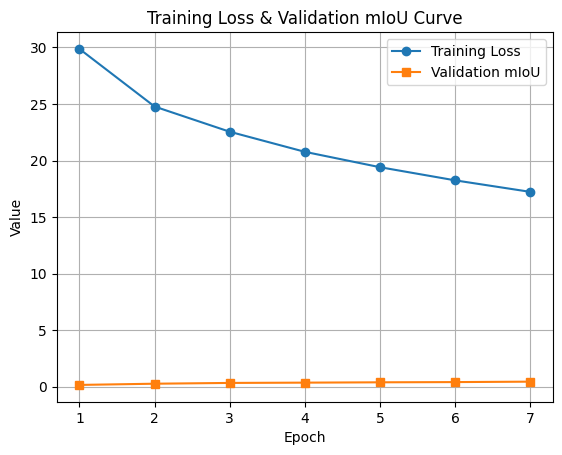

In [ ]:
import torch
import os
import matplotlib.pyplot as plt

checkpoint_dir = "/content/drive/MyDrive/weights_mask2former"

train_losses = []
val_miou = []
epochs = []

files = sorted([f for f in os.listdir(checkpoint_dir) if f.startswith("checkpoint_epoch")])

for file in files:
    path = os.path.join(checkpoint_dir, file)

    # ✅ FIX HERE
    checkpoint = torch.load(path, map_location='cpu', weights_only=False)

    epoch = checkpoint.get('epoch', 0)
    loss = checkpoint.get('train_loss', None)
    metrics = checkpoint.get('val_metrics', {})

    if loss is not None:
        train_losses.append(loss)
        val_miou.append(metrics.get('mIoU', 0))
        epochs.append(epoch + 1)

# 🔹 Plot
plt.figure()

plt.plot(epochs, train_losses, marker='o', label="Training Loss")
plt.plot(epochs, val_miou, marker='s', label="Validation mIoU")

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training Loss & Validation mIoU Curve")
plt.legend()
plt.grid()

plt.show()

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Mask2FormerForUniversalSegmentation.from_pretrained(
    "facebook/mask2former-swin-tiny-coco-panoptic"
)

checkpoint_path = "/content/drive/MyDrive/weights_mask2former/best_model.pth"

checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

if "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.to(device)
model.eval()

processor = AutoImageProcessor.from_pretrained(
    "facebook/mask2former-swin-tiny-coco-panoptic"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/190M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/538 [00:00<?, ?B/s]

The image processor of type `Mask2FormerImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [ ]:
id2label = {
    0: "background",
    1: "white_rice",
    2: "jeera_rice",
    3: "chicken_pulao",
    4: "beef_pulao",
    5: "chicken_biryani",
    6: "beef_biryani",
    7: "matar_rice",
    8: "khichdi",
    9: "egg_fried_rice",
    10: "aloo_tahari",
    11: "vegetable_pulao",
    12: "mixed_dal",
    13: "chana_dal",
    14: "maash_dal",
    15: "zarda",
    16: "meethe_chawal",
    17: "kheer",
    18: "gulab_jamun",
    19: "kulfi",
    20: "ras_malai",
    21: "barfi",
    22: "jalebi",
    23: "falooda",
    24: "rabri",
    25: "suji_halwa",
    26: "gajar_halwa",
    27: "naan",
    28: "roti",
    29: "sheermal",
    30: "puri",
    31: "paratha",
    32: "achar_pickle",
    33: "salad",
    34: "pudina_chutney_mint_chutney",
    35: "kachumber_salad",
    36: "raita",
    37: "chai_tea",
    38: "lassi",
    39: "sattu",
    40: "lemonade",
    41: "milk_soda",
    42: "coffee",
    43: "chicken_karahi",
    44: "beef_karahi",
    45: "aloo_gosht",
    46: "chicken_korma",
    47: "beef_korma",
    48: "nihari",
    49: "kunna",
    50: "keema",
    51: "fish_curry",
    52: "paye",
    53: "kofta",
    54: "bhindi",
    55: "aloo_baingan",
    56: "palak_gosht",
    57: "ghiya_bottle_gourd",
    58: "karela_bitter_gourd",
    59: "aloo_methi",
    60: "mixed_sabzi",
    61: "aloo_shimla_mirch",
    62: "saag",
    63: "aloo_gobi",
    64: "aloo_palak",
    65: "fish",
    66: "chicken_tikka",
    67: "malai_boti",
    68: "seekh_kebab",
    69: "chapli_kebab",
    70: "lamb_chops",
    71: "chicken_roast",
    72: "kadhi_pakora",
    73: "aloo_vanda_aloo_wale_parathe___aloo_snacks",
    74: "anda_paratha",
    75: "haleem",
    76: "halwa_puri",
    77: "samosa",
    78: "pakode",
    79: "chana_chaat",
    80: "gol_gappe_pani_puri",
    81: "fries",
    82: "mutton_pulao",
    83: "mutton_karahi",
    84: "mutton_biryani"
}

In [ ]:
test_dir = "/content/drive/MyDrive/TEST-DATA"
output_dir = "/content/drive/MyDrive/output_predictions"

os.makedirs(output_dir, exist_ok=True)

In [ ]:
def predict_and_visualize_no_bg(image_path, save_path, threshold=0.05):
    image = Image.open(image_path).convert("RGB")

    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    results = processor.post_process_instance_segmentation(
        outputs,
        threshold=threshold,
        target_sizes=[image.size[::-1]]
    )[0]

    segmentation = results["segmentation"].cpu().numpy()
    segments_info = results["segments_info"]

    # 🎯 Get class names (REMOVE BACKGROUND)
    detected_classes = set()
    filtered_segments = []

    for seg in segments_info:
        label_id = seg["label_id"]
        score = seg["score"]

        # ❌ SKIP BACKGROUND
        if label_id == 0:
            continue

        class_name = id2label.get(label_id, f"class_{label_id}")
        detected_classes.add((class_name, float(score)))
        filtered_segments.append(seg)

    print(f"\nImage: {os.path.basename(image_path)}")
    print("Detected Classes (NO background):")
    for cls, sc in detected_classes:
        print(f"{cls}: {sc:.4f}")

    # 🎨 Create colored mask (ONLY FOOD, NO BG)
    color_map = np.random.randint(0, 255, (100, 3))
    seg_img = np.zeros((segmentation.shape[0], segmentation.shape[1], 3), dtype=np.uint8)

    for seg in filtered_segments:
        seg_id = seg["id"]
        label_id = seg["label_id"]

        seg_img[segmentation == seg_id] = color_map[label_id]

    # Overlay
    image_np = np.array(image)
    overlay = cv2.addWeighted(image_np, 0.6, seg_img, 0.4, 0)

    # Save
    cv2.imwrite(save_path, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

    return overlay


Image: WhatsApp Image 2026-02-19 at 8.54.50 PM.jpeg
Detected Classes (NO background):


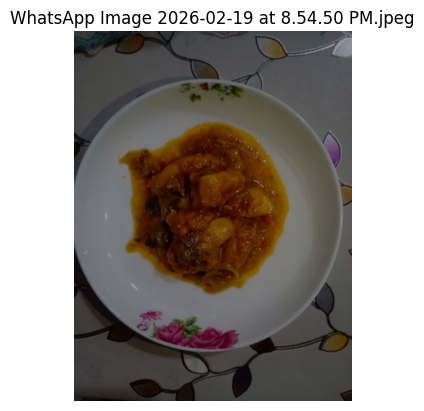


Image: WhatsApp Image 2026-02-19 at 9.03.18 PM.jpeg
Detected Classes (NO background):
halwa_puri: 0.6682
halwa_puri: 0.9748


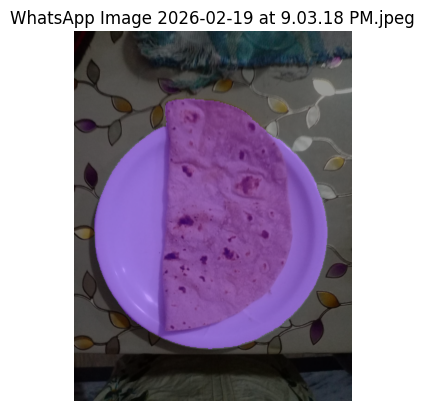


Image: ca37a86f-70ff-4ac4-b657-22e61c451095.jpeg
Detected Classes (NO background):
salad: 0.9020


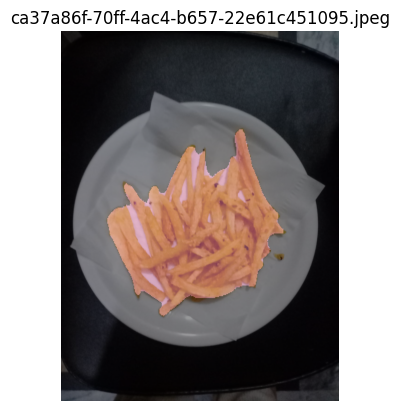


Image: a81efd49-de39-4a00-acdd-04a55277804a.jpeg
Detected Classes (NO background):
anda_paratha: 0.7887


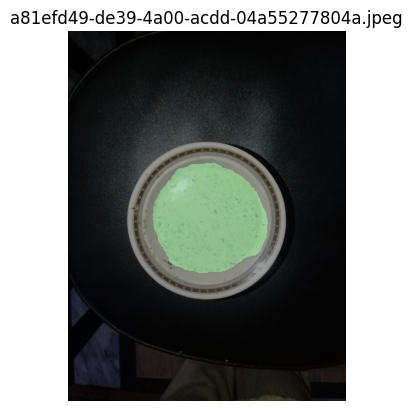


Image: 939f09f1-102b-4777-8116-d4065d605ab2.jpeg
Detected Classes (NO background):


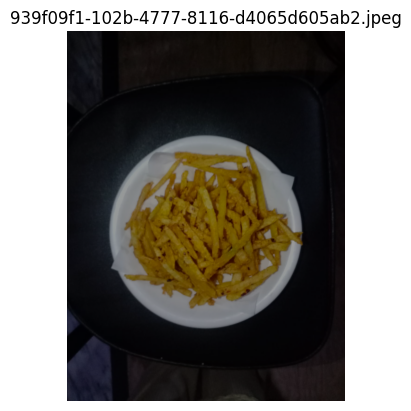


Image: 1f2f2892-856a-4c8b-87ed-1ec34bad7573.jpeg
Detected Classes (NO background):


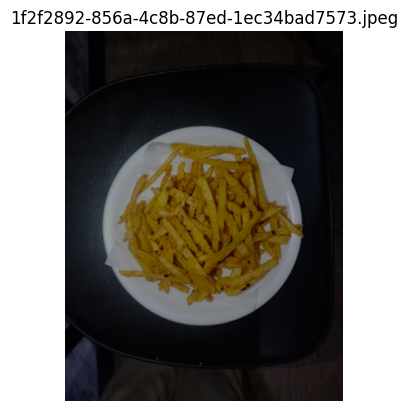


Image: 202a7081-606d-4520-a4d2-fd65581fcc6a.jpeg
Detected Classes (NO background):
chana_chaat: 0.7275


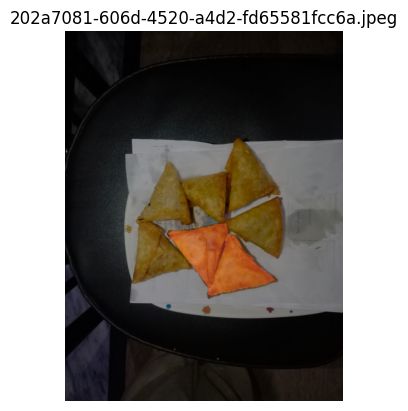


Image: 043ec541-f164-4d98-872d-d9e39b8567bc.jpeg
Detected Classes (NO background):
chana_chaat: 0.5488
chana_chaat: 0.5049


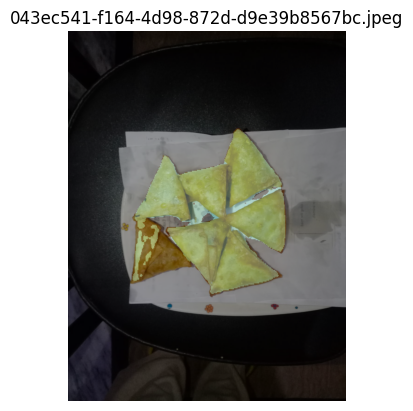


Image: 1a4a3136-270f-46da-9dd4-d06e94494f1f.jpeg
Detected Classes (NO background):


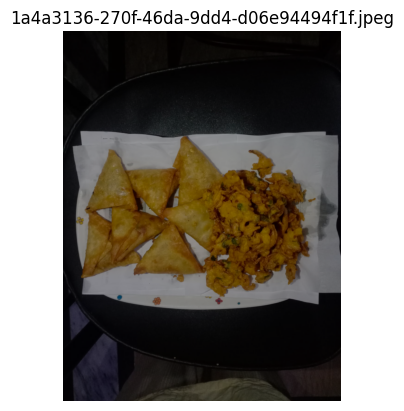


Image: 9433491e-e852-49e9-a75d-a9c2e86a6f45.jpeg
Detected Classes (NO background):


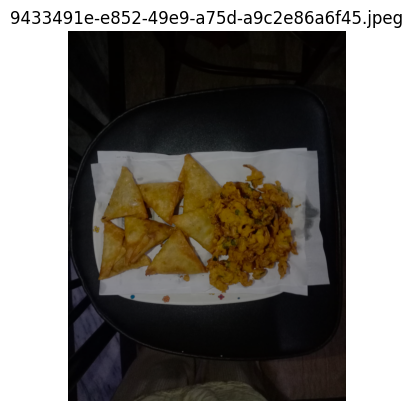

In [ ]:
for img_name in os.listdir(test_dir):
    img_path = os.path.join(test_dir, img_name)
    save_path = os.path.join(output_dir, img_name)

    try:
        overlay = predict_and_visualize_no_bg(img_path, save_path, threshold=0.5)

        plt.imshow(overlay)
        plt.title(img_name)
        plt.axis("off")
        plt.show()

    except Exception as e:
        print(f"Error processing {img_name}: {e}")